In [2]:

## Boyd 1
#start_time = "2015-12-20T12:00"
#end_time = "2015-12-22T04:20"
#out_name = '/mnt/i/Google Drive - UMBC/Manuscripts/PSD Paper/boyd1-omni.png'

## Boyd 2
#start_time = "2015-11-30T13:10"
#end_time = "2015-12-02T00:55"
#out_name = '/mnt/i/Google Drive - UMBC/Manuscripts/PSD Paper/boyd2-omni.png'

## Boyd 3
start_time = "2025-09-27T00:00:00"
end_time = "2025-10-7T00:00:00"
out_name = './plots/storm_sept30.png'
#target_time = "1997-10-10T17:04:00"

In [3]:
from cdasws import CdasWs

# Set list of variable names to load. This can be made to download only what you need.
# Variables not listed here are "support variables" and will be pulled in automatically.
variables = [
   "BX_GSE",
   "BY_GSM",
   "BZ_GSM",
   "Pressure",
   "SYM_H",
]
    
cdas = CdasWs()

# Get the data. If this issues a UserWarning about Nanoseconds, it is harmless
status, data_xarray = cdas.get_data("OMNI_HRO_1MIN", variables, start_time, end_time)

print("Request Status:", status)
print(data_xarray)

/home/dedasilv/micromamba/envs/tracers-dispersion-detection/lib/python3.11/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()


Request Status: {'http': {'status_code': 200}, 'cdas': {'status': [], 'message': [], 'warning': [], 'error': []}}
{'Epoch': VarCopy([datetime.datetime(2025, 9, 27, 0, 0),
         datetime.datetime(2025, 9, 27, 0, 1),
         datetime.datetime(2025, 9, 27, 0, 2), ...,
         datetime.datetime(2025, 10, 6, 23, 58),
         datetime.datetime(2025, 10, 6, 23, 59),
         datetime.datetime(2025, 10, 7, 0, 0)], dtype=object), 'BX_GSE': VarCopy([-3.87, -4.05, -4.  , ...,  2.25,  2.29,  1.95], dtype=float32), 'BY_GSM': VarCopy([-2.02, -1.66, -1.88, ...,  4.81,  5.18,  5.43], dtype=float32), 'BZ_GSM': VarCopy([ 1.34,  1.31,  1.16, ..., -4.69, -4.39, -4.24], dtype=float32), 'Pressure': VarCopy([ 2.  ,  2.  ,  2.  , ...,  1.15, 99.99, 99.99], dtype=float32), 'SYM_H': VarCopy([  2,   2,   2, ..., -15, -15, -15], dtype=int32)}


In [4]:
omni_epoch = data_xarray['Epoch']
omni_Bx = data_xarray['BX_GSE']
omni_By = data_xarray['BY_GSM']
omni_Bz = data_xarray['BZ_GSM']
omni_dynpres = data_xarray['Pressure']
symh = data_xarray['SYM_H']

fill_value = 9999
omni_Bx[omni_Bx>fill_value] = np.nan
omni_By[omni_By>fill_value] = np.nan
omni_Bz[omni_Bz>fill_value] = np.nan

fill_value = 99
omni_dynpres[omni_dynpres>=fill_value] = np.nan

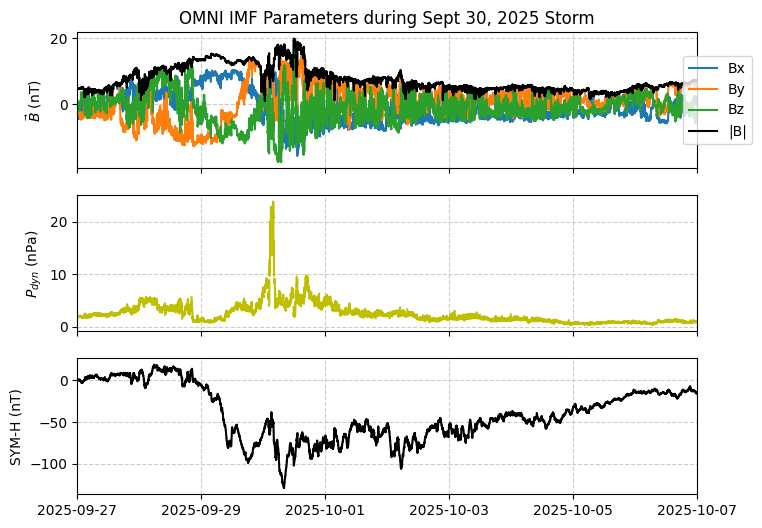

In [17]:

import pylab as plt, numpy as np
from matplotlib import dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
#plt.subplots_adjust(left=0.1,
#                    bottom=0.1, 
#                    right=0.9, 
#                    top=0.9, 
#                    wspace=0.4, 
#                    hspace=0)


axes[0].plot(omni_epoch, omni_Bx, label='Bx')
axes[0].plot(omni_epoch, omni_By, label='By')
axes[0].plot(omni_epoch, omni_Bz, label='Bz')
axes[0].plot(omni_epoch, np.sqrt(omni_Bx**2 + omni_By**2 + omni_Bz**2), label='|B|', color='k')
axes[0].legend(ncol=1, bbox_to_anchor=(1.1, .5), loc='center right')
axes[0].set_ylabel('$\\vec{B}$ (nT)')
axes[1].plot(omni_epoch, omni_dynpres, color='y')
axes[1].set_ylabel('$P_{dyn}$ (nPa)')
axes[2].plot(omni_epoch, symh, color='k')
axes[2].set_ylabel('SYM-H (nT)')

for ax in axes:
    import dateutil.parser
    ax.grid(linestyle='dashed', color='#ccc')
    ax.set_xlim(data_xarray['Epoch'].min(), dateutil.parser.parse(end_time))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

#axes[0].axvline(dateutil.parser.parse(target_time), color='r')
axes[0].set_title('OMNI IMF Parameters during Sept 30, 2025 Storm')
plt.savefig(out_name, dpi=300)